# 04. Evaluación Global: SLM vs LLM vs RAG Dual (LLM-as-a-Judge)

## Objetivos del Notebook
Este notebook ejecuta la prueba final del TFG sometiendo una batería de preguntas (CSV) a 4 configuraciones distintas:
1. **SLM Base (Local):** Phi-3-mini-4k-instruct respondiendo de memoria (sin RAG).
2. **LLM Avanzado (Nube):** Gemini 2.5 Flash respondiendo de memoria (sin RAG).
3. **RAG Léxico (BM25 + SLM):** Nuestro sistema RAG tradicional usando palabras clave.
4. **RAG Semántico (Vectores + SLM):** Nuestro sistema RAG avanzado usando embeddings (BGE-M3) y kNN.

## Metodología de Evaluación
Utilizaremos el paradigma **LLM-as-a-Judge**. Un modelo externo, rápido y eficiente (`gemini-2.5-flash-lite`), leerá la "Respuesta Esperada" de nuestro CSV y la comparará con la respuesta generada por cada uno de los 4 sistemas. Evaluará si la esencia de la respuesta es "CORRECTA" o "INCORRECTA". Finalmente, visualizaremos los resultados en un gráfico de barras.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Cargamos variables de entorno (Asegúrate de tener tu archivo .env con GEMINI_API_KEY)
load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    print("ADVERTENCIA: No se encontró GEMINI_API_KEY en el entorno.")
else:
    print("API Key de Gemini cargada correctamente.")

API Key de Gemini cargada correctamente.


In [2]:
import torch
from elasticsearch import Elasticsearch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# 1. Cargamos el CSV con las preguntas
# (Asegúrate de que las columnas se llamen 'Pregunta' y 'Respuesta_Esperada')
df_preguntas = pd.read_csv("bateria_preguntas_tfg.csv")
print(f"Batería de preguntas cargada: {len(df_preguntas)} preguntas listas para evaluar.")

# 2. Inicializamos Infraestructura Local
print("Conectando a Elasticsearch...")
es = Elasticsearch("http://127.0.0.1:9250")
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Cargando BGE-M3 (Vectores)...")
embed_model = SentenceTransformer('BAAI/bge-m3', device=device)

print("Cargando Phi-3 (SLM)...")
MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=False)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, device_map="auto", torch_dtype=torch.float16)
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

# 3. INYECCIÓN EN RAG_ENGINE
import rag_engine
rag_engine.es = es
rag_engine.embed_model = embed_model
rag_engine.pipe = pipe

print("Modelos locales cargados y enlazados a rag_engine.py")

/home/javierruiz/miniconda3/envs/environment/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Batería de preguntas cargada: 56 preguntas listas para evaluar.
Conectando a Elasticsearch...
Cargando BGE-M3 (Vectores)...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 3577.92it/s, Materializing param=pooler.dense.weight]                               


Cargando Phi-3 (SLM)...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 195/195 [00:01<00:00, 124.22it/s, Materializing param=model.norm.weight]                              


Sistema RAG (k=1) reconfigurado para devolver datos separados.
Sistema RAG Vectorial (k=1) configurado.
Modelos locales cargados y enlazados a rag_engine.py


In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. El LLM Avanzado (Caso 2)
gemini_avanzado = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    temperature=0, # Determinista
    google_api_key=GEMINI_API_KEY
)

# 2. El Juez (LLM-as-a-judge)
llm_juez = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite", 
    temperature=0, 
    google_api_key=GEMINI_API_KEY
)

prompt_evaluacion = ChatPromptTemplate.from_messages([
    ("system", """Eres un evaluador comprensivo de sistemas RAG. 
    Tu tarea es comparar la 'Respuesta Esperada' con la 'Respuesta Generada'.
    
    Regla fundamental: Si la Respuesta Generada contiene la idea principal o la solución básica de la Respuesta Esperada, debes darla por válida, aunque falten detalles menores o la redacción sea muy distinta. 
    
    Responde ÚNICAMENTE con la palabra "CORRECTO" si la esencia es la misma, o "INCORRECTO" si la IA dice que no tiene información, si se contradice o si la idea principal es totalmente errónea."""),
    ("human", "Respuesta Esperada:\n{esperada}\n\nRespuesta Generada por el RAG:\n{generada}")
])

juez_chain = prompt_evaluacion | llm_juez | StrOutputParser()
print("Modelos de Google y Sistema de Evaluación Juez configurados.")

Modelos de Google y Sistema de Evaluación Juez configurados.


In [10]:
def caso1_slm_base(pregunta):
    """Caso 1: Phi-3 responde de memoria"""
    messages = [{"role": "user", "content": pregunta}]
    out = pipe(messages, max_new_tokens=150, do_sample=False, temperature=0.0)
    return out[0]['generated_text'][-1]['content'].strip()

def caso2_llm_avanzado(pregunta):
    """Caso 2: Gemini 2.5 Flash responde de memoria"""
    respuesta = gemini_avanzado.invoke(pregunta)
    return respuesta.content.strip()

def caso3_rag_bm25(pregunta):
    """Caso 3: RAG Léxico con Phi-3"""
    resultado = rag_engine.ask_rag(pregunta, top_k=2)
    return resultado.get('respuesta_rag', resultado.get('error', 'Error desconocido'))

def caso4_rag_vectorial(pregunta):
    """Caso 4: RAG Semántico con Phi-3"""
    resultado = rag_engine.ask_rag_vectorial(pregunta, top_k=2)
    return resultado.get('respuesta_rag', resultado.get('error', 'Error desconocido'))

In [11]:
import transformers
import warnings

# 1. Silenciamos la charla interna de Hugging Face (solo mostrará errores críticos)
transformers.logging.set_verbosity_error()

# 2. Silenciamos los avisos estándar de Python
warnings.filterwarnings("ignore")

In [12]:
import time
from tqdm import tqdm
print("Ping a Elasticsearch:", es.ping())
resultados = []

print("Iniciando evaluación de los 4 casos para cada pregunta...")

# Iteramos sobre el CSV (usamos tqdm para ver la barra de progreso)
for index, row in tqdm(df_preguntas.iterrows(), total=len(df_preguntas)):
    pregunta = row['pregunta']
    esperada = row['respuesta_esperada']
    
    # 1. Generamos las 4 respuestas
    resp_c1 = caso1_slm_base(pregunta)
    resp_c2 = caso2_llm_avanzado(pregunta)
    resp_c3 = caso3_rag_bm25(pregunta)
    resp_c4 = caso4_rag_vectorial(pregunta)
    
    # 2. El Juez evalúa las 4 respuestas
    eval_c1 = juez_chain.invoke({"esperada": esperada, "generada": resp_c1}).strip().upper()
    eval_c2 = juez_chain.invoke({"esperada": esperada, "generada": resp_c2}).strip().upper()
    eval_c3 = juez_chain.invoke({"esperada": esperada, "generada": resp_c3}).strip().upper()
    eval_c4 = juez_chain.invoke({"esperada": esperada, "generada": resp_c4}).strip().upper()
    
    # 3. Guardamos en el registro
    resultados.append({
        "Pregunta": pregunta,
        "Esperada": esperada,
        "C1_SLM_Resp": resp_c1, "C1_Eval": eval_c1,
        "C2_LLM_Resp": resp_c2, "C2_Eval": eval_c2,
        "C3_BM25_Resp": resp_c3, "C3_Eval": eval_c3,
        "C4_VECT_Resp": resp_c4, "C4_Eval": eval_c4
    })
    
    # Pequeña pausa para no saturar la API gratuita de Gemini
    time.sleep(1) 

# Convertimos a DataFrame para analizar cómodamente
df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv("resultados_evaluacion_tfg.csv", index=False)
print("Evaluación terminada. Resultados guardados en 'resultados_evaluacion_tfg.csv'.")

Ping a Elasticsearch: True
Iniciando evaluación de los 4 casos para cada pregunta...


100%|██████████| 56/56 [38:34<00:00, 41.32s/it]

Evaluación terminada. Resultados guardados en 'resultados_evaluacion_tfg.csv'.


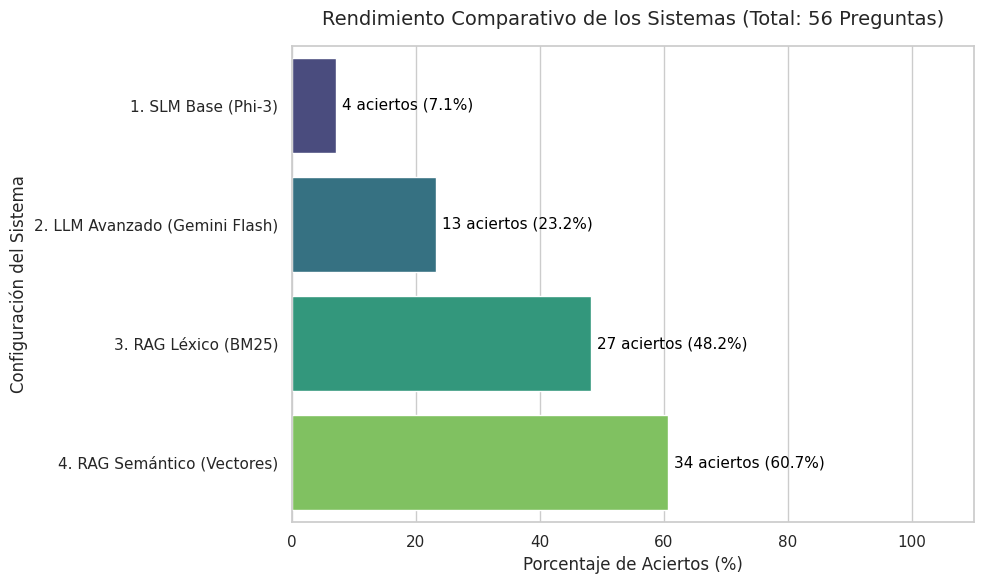

In [13]:
# Contamos cuántos "CORRECTO" sacó cada modelo
aciertos = {
    "1. SLM Base (Phi-3)": (df_resultados['C1_Eval'] == 'CORRECTO').sum(),
    "2. LLM Avanzado (Gemini Flash)": (df_resultados['C2_Eval'] == 'CORRECTO').sum(),
    "3. RAG Léxico (BM25)": (df_resultados['C3_Eval'] == 'CORRECTO').sum(),
    "4. RAG Semántico (Vectores)": (df_resultados['C4_Eval'] == 'CORRECTO').sum()
}

# Preparamos los datos para el gráfico
nombres = list(aciertos.keys())
valores = list(aciertos.values())
total_preguntas = len(df_resultados)
porcentajes = [(v / total_preguntas) * 100 for v in valores]

# Creamos el gráfico con estilo profesional para tu TFG
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=porcentajes, y=nombres, palette="viridis")

# Añadimos las etiquetas con el número exacto y el porcentaje
for p, val, perc in zip(ax.patches, valores, porcentajes):
    ax.annotate(f"{val} aciertos ({perc:.1f}%)", 
                (p.get_width() + 1, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=11, color='black')

plt.xlim(0, 110) # Damos margen a la derecha para que quepa el texto
plt.title(f'Rendimiento Comparativo de los Sistemas (Total: {total_preguntas} Preguntas)', fontsize=14, pad=15)
plt.xlabel('Porcentaje de Aciertos (%)', fontsize=12)
plt.ylabel('Configuración del Sistema', fontsize=12)
plt.tight_layout()

# Guardamos el gráfico como imagen para pegarlo directo en el PDF de tu TFG
plt.savefig("grafico_rendimiento_tfg.png", dpi=300)
plt.show()